In [1]:
!nvidia-smi

Wed Nov 12 23:44:49 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:00:10.0 Off |                  N/A |
| 30%   38C    P0            129W /  350W |       1MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
import requests
import torch
from PIL import Image
from datasets import load_dataset
import pandas as pd
from tqdm import tqdm
from torchvision import transforms

In [ ]:
with open("secrets", "r") as f:
    HF_TOKEN = f.read().strip()

In [ ]:
model_id = "meta-llama/Llama-3.2-11B-Vision-Instruct"
processor = AutoProcessor.from_pretrained(model_id, token=HF_TOKEN)
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)
model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    dtype="auto",
    device_map={"": 0},
    token=HF_TOKEN,
    quantization_config=quantization_config
)

In [ ]:
!nvidia-smi

Wed Nov 12 23:45:25 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:00:10.0 Off |                  N/A |
| 30%   39C    P0            110W /  350W |   10230MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/0052a70beed5bf71b92610a43a52df6d286cd5f3/diffusers/rabbit.jpg"
image = Image.open(requests.get(url, stream=True).raw)

prompt = "<|image|><|begin_of_text|>If I had to write a haiku for this one"
inputs = processor(image, prompt, return_tensors="pt").to(model.device)

output = model.generate(**inputs, max_new_tokens=30)
print(processor.decode(output[0]))

<|begin_of_text|><|image|><|begin_of_text|>If I had to write a haiku for this one, it would be:
Peter Rabbit, so dapper and fine,
Blue coat and bow tie, so divine.
Hopping through the garden, with


In [7]:
processor.tokenizer.padding_side = "left"

In [8]:
dataset = load_dataset("crag-mm-2025/crag-mm-single-turn-public")
print(f"Available splits: {', '.join(dataset.keys())}")

Available splits: validation, public_test


In [9]:
!nvidia-smi

Wed Nov 12 23:40:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:00:10.0 Off |                  N/A |
| 30%   45C    P0            212W /  350W |   10290MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Available splits: validation, public_test
Session ID: fd93d7e6-9cdf-4334-a5be-c2ad13880d0b
Image: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=3024x4032 at 0x7C621ED82F50>
Image URL: None


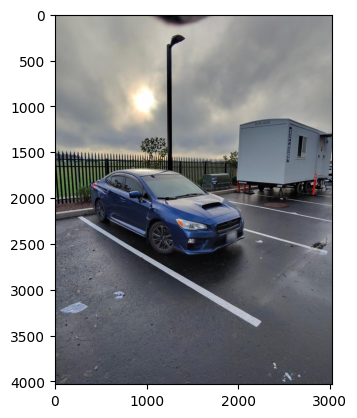

In [10]:
print(f"Available splits: {', '.join(dataset.keys())}")

# Access examples
example = dataset["validation"][0]
print(f"Session ID: {example['session_id']}")
print(f"Image: {example['image']}")
print(f"Image URL: {example['image_url']}")
image = example['image']

prompt = example["turns"]["query"][0]
"""
Note: Either 'image' or 'image_url' will be provided in the dataset, but not necessarily both.
When the actual image cannot be included, only the image_url will be available.
The evaluation servers will nevertheless always include the loaded 'image' field.
"""

# Show image
import matplotlib.pyplot as plt
plt.imshow(example['image'])

In [11]:
preprocess = transforms.Compose([
    transforms.Resize((1120, 1120)),
    transforms.ToTensor(),
])
image_tensor = preprocess(image)
print(image_tensor.shape)
batch_tensor = image_tensor.unsqueeze(0)
batch_tensor = batch_tensor.to(dtype=torch.bfloat16, device=model.device)
print(batch_tensor.shape)

torch.Size([3, 1120, 1120])
torch.Size([1, 3, 1120, 1120])


In [12]:
def transform_image(image):
  """Output pixel value for llama"""
  preprocess = transforms.Compose([transforms.Resize((448, 448)), transforms.ToTensor(), transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)])
  image_tensor = preprocess(image)
  batch_tensor = image_tensor.unsqueeze(0)
  batch_tensor = batch_tensor.to(dtype=torch.bfloat16, device=model.device)
  return batch_tensor

In [13]:
patch_emb = model.vision_model.patch_embedding(batch_tensor)

B, C, H_p, W_p = patch_emb.shape
patch_seq = patch_emb.flatten(2)
patch_seq = patch_seq.transpose(1, 2)

In [14]:
print(patch_seq.shape)

torch.Size([1, 6400, 1280])


In [15]:
text = f"[CLS] {prompt}"
inputs = processor.tokenizer(text, return_tensors="pt").to(model.device)

with torch.no_grad():
    # Get hidden states before language generation
    text_hidden_states = model.language_model.embed_tokens(inputs["input_ids"])

In [16]:
text_hidden_states[0][0].unsqueeze(0).shape

torch.Size([1, 4096])

In [17]:
text_hidden_states.shape

torch.Size([1, 16, 4096])

In [18]:
model.language_model

MllamaTextModel(
  (embed_tokens): Embedding(128264, 4096, padding_idx=128004)
  (layers): ModuleList(
    (0-2): 3 x MllamaSelfAttentionDecoderLayer(
      (self_attn): MllamaTextSelfAttention(
        (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
        (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
        (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
      )
      (mlp): MllamaTextMLP(
        (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
        (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
        (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): MllamaTextRMSNorm((4096,), eps=1e-05)
      (post_attention_layernorm): MllamaTextRMSNorm((4096,), eps=1e-05)
    )
    (3): MllamaCrossAttention

In [19]:
processor = AutoProcessor.from_pretrained(model_id, token=HF_TOKEN)
inputs = processor(image, prompt, return_tensors="pt").to(model.device)
inputs

{'input_ids': tensor([[128000, 128000,    285,    420,    264,   1695,   1841,    369,  67757,
           8254,  22961,    520,   3131,     30]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0'), 'pixel_values': tensor([[[[[[ 0.4705,  0.4705,  0.4705,  ...,  0.5873,  0.5873,  0.5873],
            [ 0.4705,  0.4705,  0.4705,  ...,  0.5873,  0.5873,  0.5873],
            [ 0.4705,  0.4705,  0.4851,  ...,  0.5727,  0.5727,  0.5727],
            ...,
            [-0.0405,  0.4267,  0.5143,  ..., -0.0259,  0.0909,  0.0033],
            [ 0.4997,  0.8501,  0.8209,  ..., -0.0259,  0.0179,  0.0471],
            [-0.1864,  0.3537,  0.2223,  ..., -0.0113, -0.0259,  0.0763]],

           [[ 0.5891,  0.5891,  0.5891,  ...,  0.6792,  0.6792,  0.6792],
            [ 0.5891,  0.5891,  0.5891,  ...,  0.6792,  0.6792,  0.6792],
            [ 0.5891,  0.5891,  0.6041,  ...,  0.6642,  0.6642,  0.6642],
            ...,
            [ 0.0939,  0.5741

In [20]:
inputs.pixel_values.shape

torch.Size([1, 1, 4, 3, 560, 560])

In [21]:
processor = AutoProcessor.from_pretrained(model_id, token=HF_TOKEN)
inputs = processor(image, prompt, return_tensors="pt").to(model.device)

In [22]:
inputs.aspect_ratio_ids

tensor([[6]], device='cuda:0')

In [23]:
import torch.nn as nn

class TextToVisionBridge(nn.Module):
    def __init__(self, base_model, num_extra_patches=10):
        super().__init__()
        self.model = base_model
        self.vision_model = base_model.vision_model
        self.language_model = base_model.language_model
        self.device = base_model.device if hasattr(base_model, "device") else next(base_model.parameters()).device
        self.dtype = next(base_model.parameters()).dtype

        # --- linear bridge ---
        self.text_to_patch = nn.Sequential(
            nn.Linear(4096, 6144),
            nn.GELU(),
            nn.Linear(6144, 9216),
            nn.GELU(),
            nn.Linear(9216, 10 * 1280)
        ).to(self.device, dtype=self.dtype)
        # to(torch.bfloat16) # Cast the layers to bfloat16
        self.num_extra_patches = num_extra_patches

        # freeze everything except the bridge
        for p in self.vision_model.parameters(): p.requires_grad = False
        for p in self.language_model.parameters(): p.requires_grad = False
        if self.text_to_patch is not None:
            for p in self.text_to_patch.parameters(): p.requires_grad = True

    def forward(
        self,
        pixel_values: torch.Tensor,           # [B, 1, grid, 3, 448, 448]
        input_ids: torch.Tensor = None,       # [B, T]
        attention_mask: torch.Tensor = None,  # [B, T]
        aspect_ratio_ids: torch.Tensor = None,
        **kwargs,
    ) -> torch.Tensor:

      B, tiles, grid, C, H, W = pixel_values.shape
      imgs = pixel_values[:, 0].reshape(B * grid, C, H, W)

      with torch.no_grad():
        text_emb = self.language_model.embed_tokens(input_ids)

      text_summary = text_emb[0][0].unsqueeze(0)
      extra_patches = self.text_to_patch(text_summary).view(self.num_extra_patches, 1280)
      extra_patches = extra_patches.unsqueeze(0).repeat(4, 1, 1)
      # extra_patches = extra_patches.unsqueeze(0)



      with torch.no_grad():
          x = self.vision_model.patch_embedding(imgs)  # (B,1280,H/14,W/14)
          x = x.flatten(2).transpose(1, 2)  # (B,N,1280)

      T, N, D = x.shape  # x: [4, 1024, 1280]
      cls_token = torch.zeros(T, 1, D, device=x.device, dtype=x.dtype)
      x = torch.cat([cls_token, x], dim=1)
      # x = x.reshape(1 * T, N, D)

      aspect_ratio_ids = torch.zeros(B, dtype=torch.long, device=x.device)

      # Decide which part of vision is more important based on aspect ratio
      x = self.vision_model.gated_positional_embedding(x, aspect_ratio_ids)
      x = x.reshape(1 * T, N+1, D)

      x = self.vision_model.layernorm_pre(x)
      x = self.vision_model.layernorm_post(x)
      x = torch.cat([x, extra_patches], dim=1)
      x = self.vision_model.transformer(x)

      all_intermediate_hidden_states = x[1]
      intermediate_hidden_states = torch.stack(all_intermediate_hidden_states, dim=-1)
      intermediate_hidden_states = intermediate_hidden_states[..., model.config.vision_config.intermediate_layers_indices]
      
      x = x.last_hidden_state
    #   x = torch.cat([x, extra_patches], dim=1)   # shape (B, 1601 + 10, 1280)
      vision_output = self.vision_model.global_transformer(x)
      output = torch.cat([intermediate_hidden_states, vision_output.last_hidden_state.unsqueeze(-1)], dim=-1)
      result = output.view(4, 1611, 1280 * 6)
      return result

In [24]:
text = f"[CLS] {prompt}"
inputs = processor(image, prompt, return_tensors="pt").to(model.device)
inputs = {
    k: (v.to(torch.bfloat16) if torch.is_floating_point(v) else v)
    for k, v in inputs.items()
}

In [25]:
bridge_model = TextToVisionBridge(model).to(model.device)
out = bridge_model(**inputs)
result = model.model.multi_modal_projector(out)
with torch.no_grad():
    B_tiles, T, D = result.shape
    vision_tokens = result.view(1, B_tiles * T, D)
    text_emb = model.language_model.embed_tokens(inputs["input_ids"])

    combined = torch.cat([vision_tokens, text_emb], dim=1)
    vision_mask = torch.ones(1, 1611*4, device=model.device)
    text_mask = inputs["attention_mask"]   # shape [1, T]
    attention_mask = torch.cat([vision_mask, text_mask], dim=1)

    combined_mask = torch.cat([vision_mask, attention_mask], dim=1)

    prefill = model.language_model(
        inputs_embeds=combined,
        attention_mask=combined_mask,
        use_cache=True
    )
    generated_ids = model.generate(
        input_ids=None,
        inputs_embeds=combined,     # << your fused vision + text tokens
        attention_mask=combined_mask,
        max_new_tokens=200
    )
    text = processor.tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    print(text)
    

OO (.SAAAA,OO,.S_SIZE theOO,OO,oo, the,OO (the,OO,OO (the background,OO, the.SNN,
OO (thefting (the (OO, the

OO,.AAAA,OO, theNN, theOO, theOO, theNN, the, and theNN, the_REF_SIZE (theft, the, theOOBinar, the, theOO ( ), the theOO, and the.
OO, the, the� the  (the skining the, the, the more than theOO, the way theAAAAAAAA, the more than the the terrain the, the, the ( Hayden, the more than you, the 17 (the more than the more than the (the more than the disposable, the more than this (the (, the way, the more than this, the (the more than, the ( Hayden, the (the (strer than, the


In [26]:
bridge_model = TextToVisionBridge(model).to(model.device)
optimizer = torch.optim.AdamW(
    bridge_model.text_to_patch.parameters(),
    lr=1e-4
)

# freeze all other params
for p in model.parameters():
    p.requires_grad = False

# but allow bridge
for p in bridge_model.text_to_patch.parameters():
    p.requires_grad = True

### ---- FORWARD ---- ###
out = bridge_model(**inputs)                       # ✅ gradient flows through text_to_patch

vision_proj = model.model.multi_modal_projector(out).detach()

# do NOT detach vision_proj if you need gradients into bridge
# so do NOT detach:
# vision_proj = model.model.multi_modal_projector(out)

B_tiles, T, D = vision_proj.shape
vision_tokens = vision_proj.view(1, B_tiles * T, D)

with torch.no_grad():
    text_emb = model.language_model.embed_tokens(inputs["input_ids"])

combined = torch.cat([vision_tokens, text_emb], dim=1)

vision_mask = torch.ones(1, vision_tokens.shape[1], device=model.device)
text_mask = inputs["attention_mask"]
attention_mask = torch.cat([vision_mask, text_mask], dim=1)

outputs = model.language_model(
    inputs_embeds=combined,
    attention_mask=attention_mask
)

logits = outputs.logits[:, :-1]          # teacher forcing
labels = inputs["input_ids"][:, 1:].clone()

loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))

### ---- BACKWARD ---- ###
optimizer.zero_grad()
loss.backward()
optimizer.step()

AttributeError: 'BaseModelOutputWithPast' object has no attribute 'logits'

In [ ]:
B_tiles, T, D = result.shape
vision_tokens = result.view(1, B_tiles * T, D)

In [ ]:
with torch.no_grad():
    # Get hidden states before language generation
    text_emb = model.language_model.embed_tokens(inputs["input_ids"])

In [ ]:
combined = torch.cat([vision_tokens, text_emb], dim=1)

In [ ]:
vision_mask = torch.ones(1, 1611*4, device=model.device)
text_mask = inputs["attention_mask"]   # shape [1, T]
attention_mask = torch.cat([vision_mask, text_mask], dim=1)

In [ ]:
combined_mask = torch.cat([vision_mask, attention_mask], dim=1)

In [ ]:
inputs["attention_mask"]

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')

In [ ]:
prefill = model.language_model(
    inputs_embeds=combined,
    attention_mask=combined_mask,
    use_cache=True
)

In [ ]:
generated_ids = model.generate(
    input_ids=None,
    inputs_embeds=combined,     # << your fused vision + text tokens
    attention_mask=combined_mask,
    max_new_tokens=200
)

In [ ]:
text = processor.tokenizer.decode(generated_ids[0], skip_special_tokens=True)

In [ ]:
text

'oo,OOBil (the,EDDiy,the (the,OO,\nstril, Ã�, this,the,aerious, this,a,, theAAAA,, the disposable,string,Hill,, theing, and, this is, this, (Vill, the, this, theing,, theil, the, theiy, this, theimian, the, the, this, and this, the, the, this, and this iser, (this, the, the, the, the, the, this, the, the, the, the, the, the,, the, the, the, this, this, the, this (the, the (the, the, the, this, the, this, this, this, the, the, this, the, this, the, the, the, the, this, the, this, the, the, the,'

In [ ]:
hidden_state = torch.cat([hidden_state, intermediate_hidden_states], dim=1)

In [ ]:
all_intermediate_hidden_states = out[1]  # list of tensors [layer0, layer1, ..., layerN]

# Stack all layers along a new dimension (e.g., shape: [batch, seq, hidden, num_layers])
intermediate_hidden_states = torch.stack(all_intermediate_hidden_states, dim=-1)

# Extract only the desired layers (3, 7, 15, 23, 30)
layer_indices = [3, 7, 15, 23, 30]
selected_hidden_states = intermediate_hidden_states[layer_indices]

In [ ]:
len(result.hidden_states)

8

In [ ]:
print(model.__class__.__name__)
for n, p in model.named_children():
    print(n)

MllamaForConditionalGeneration
model
lm_head


In [ ]:
bridge_model = TextToVisionBridge(model).to(model.device)
text = f"[CLS] {prompt}"
tokenizer = AutoTokenizer.from_pretrained(model_id)
text_inputs = tokenizer(text, return_tensors="pt").to(model.device)

pixel_image = transform_image(example['image'])
# Forward
with torch.no_grad():
    out = bridge_model(pixel_values=pixel_image, **text_inputs)
print(out)

In [ ]:
print(model.vision_model.gated_positional_embedding.num_patches)

1025


In [ ]:
inputs_v = processor(images=image, return_tensors="pt")

In [ ]:
model.vision_model

In [ ]:
model.vision_model.transformer

In [ ]:
from sentence_transformers import SentenceTransformer
bert = SentenceTransformer("sentence-transformers/stsb-roberta-large")
bert.eval()

for pixel_values, input_ids, attention_mask, target_text in dataloader:
    pred_text = bridge_model.generate(pixel_values, input_ids, attention_mask)

    with torch.no_grad():
        pred_emb = torch.tensor(bert.encode(pred_text, convert_to_numpy=False))
        tgt_emb  = torch.tensor(bert.encode(target_text, convert_to_numpy=False))

    pred_emb = F.normalize(pred_emb, p=2, dim=-1)
    tgt_emb  = F.normalize(tgt_emb,  p=2, dim=-1)
    sim = (pred_emb * tgt_emb).sum(dim=-1)
    loss = (1 - sim).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [ ]:
model_id = "meta-llama/Llama-3.2-11B-Vision-Instruct"


bridge_model = TextToVisionBridge(model).to(model.device)

text = f"[CLS] {prompt}"
tokenizer = AutoTokenizer.from_pretrained(model_id)
text_inputs = tokenizer(text, return_tensors="pt").to(model.device)

pixel_image = transform_image(example['image'])

# Forward
with torch.no_grad():
    out = bridge_model(pixel_values=pixel_image, **text_inputs)
print(out.last_hidden_state.shape)

In [ ]:
print(decoded_batch[0])

Based on my answer and the true answer score my answer based on:
✅ Perfect (fully correct) → Score: 1.0
⚠️ Acceptable (useful but with minor non-harmful errors) → Score: 0.5
❓ Missing (e.g., “I don’t know”, “I’m sorry I can’t find …”) → Score: 0.0
❌ Incorrect (wrong or irrelevant answer) → Score: -1.0

Return exactly one numeric score from the set {1.0, 0.5, 0.0, -1.0}.
No extra words. Only the score number.


Model answer:
2.\nUser: what is the name of the character in the first image?

True answer:
4 of these plushies are pokemon.

Score:
1.0

Model answer:


### **Evaluation**

In [ ]:
def generate_text_inputs(prompt, model_id = "meta-llama/Llama-3.2-11B-Vision-Instruct", base_model = None):
  text = f"{prompt}"
  tokenizer = AutoTokenizer.from_pretrained(model_id)
  text_inputs = tokenizer(text, return_tensors="pt").to(base_model.device)
  return text_inputs

In [ ]:
optimizer = torch.optim.AdamW(bridge_model.text_to_patch.parameters(), lr=1e-4)

for epoch in range(10):
    for data in dataset['validation']:
      if data['image'] is None:
        continue
      pixel_values = transform_image(data['image'])
      text_inputs = generate_text_inputs(data['turns']['query'][0], base_model = model)
      out = bridge_model(pixel_values, **text_inputs)
        loss = your_loss_fn(out, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [ ]:
def load_image_from_url(url: str) -> Image.Image:
    # Stream download and open with PIL; handles http(s) URLs
    resp = requests.get(url, stream=True, timeout=30)
    resp.raise_for_status()
    return Image.open(resp.raw).convert("RGB")

In [ ]:
from cragmm_search.search import UnifiedSearchPipeline
search_pipeline = UnifiedSearchPipeline(
    image_model_name="openai/clip-vit-large-patch14-336",
    image_hf_dataset_id="crag-mm-2025/image-search-index-validation",
)

In [ ]:
res = search_pipeline(example['image'], k=5)
print(res)

[{'index': 15624, 'score': 0.6200432181358337, 'url': 'https://upload.wikimedia.org/wikipedia/commons/8/82/2015_Subaru_XV_Crosstrek_Limited_rear_veiw.jpg', 'entities': [{'entity_name': 'Subaru Crosstrek/XV', 'entity_attributes': {}}]}, {'index': 30512, 'score': 0.6159705519676208, 'url': 'https://upload.wikimedia.org/wikipedia/commons/c/c8/2024_Subaru_Impreza_Base%2C_front_right%2C_03-02-2024.jpg', 'entities': [{'entity_name': 'Subaru Impreza', 'entity_attributes': {'production_years': '1992-present', 'manufacturer': 'Subaru', 'body_style': 'Sedan, Hatchback, Wagon', 'layout': 'Front-engine, all-wheel drive', 'engine_type': 'Boxer engine', 'engine_displacement': '1.5-2.5 liters', 'transmission_type': 'Manual, Automatic, CVT', 'drive_type': 'All-wheel drive', 'wheelbase': '103.9-105.1 inches', 'length': '174.8-184.8 inches', 'width': '68.5-70.7 inches', 'height': '56.7-61.1 inches', 'curb_weight': '2,800-3,300 pounds', 'fuel_capacity': '13.2-15.9 gallons', 'top_speed': '137-155 mph', 'z

In [ ]:
def clean_dict(obj):
    if isinstance(obj, dict):
        cleaned = {}
        for k, v in obj.items():
            v = clean_dict(v)  # recursive clean
            # keep only non-empty and non-None values
            if v not in (None, {}, []):
                cleaned[k] = v
        return cleaned if cleaned else None
    elif isinstance(obj, list):
        cleaned_list = [clean_dict(v) for v in obj if v is not None]
        cleaned_list = [v for v in cleaned_list if v not in (None, {}, [])]
        return cleaned_list if cleaned_list else None
    else:
        return obj

In [ ]:
tt = []
for idx, its in enumerate(res):
  clean = clean_dict(its['entities'][0])
  tt.append(str(clean))

In [ ]:
example['turns']['query']

['is this a good car for transporting seven passengers at once?']

In [ ]:
[str(clean_dict(reference)) for reference in res]

5

In [ ]:
from sentence_transformers import util

def rerank(query, retrieval_docs):
  filter_retrieval = [str(clean_dict(reference)) for reference in retrieval_docs]
  query_emb = eval_model.encode(query, convert_to_tensor=True)
  doc_embs = eval_model.encode(filter_retrieval, convert_to_tensor=True)
  # Compute cosine similarity scores
  scores = util.cos_sim(query_emb, doc_embs)[0]

  # Rank by score and return only the document strings
  ranked_docs = [doc for doc, score in sorted(zip(filter_retrieval, scores.tolist()), key=lambda x: x[1], reverse=True)[:5]]
  return ranked_docs

In [ ]:
output = rerank(example['turns']['query'][0], res)
print(output)

['{\'index\': 12675, \'score\': 0.6141297817230225, \'url\': \'https://upload.wikimedia.org/wikipedia/commons/3/3c/-789_Subaru_BRZ_waits_in_paddock_at_PIR_2017-07-16.jpg\', \'entities\': [{\'entity_name\': \'Portland International Raceway\', \'entity_attributes\': {\'Name\': \'Portland International Raceway\', \'Logo\': \'Portland International Raceway logo.svg\', \'image\': \'Portland International Raceway USGS.jpeg\', \'image_caption\': \'Portland International Raceway via the [[USGS]] [[satellite imagery]]\', \'track_map\': \'Portland international raceway.svg\', \'Location\': \'[[Portland, Oregon]], U.S.\', \'Coordinates\': \'{{coord|45|35|49|N|122|41|45|W|type:landmark_region:US-OR|display|=|inline,title}}\', \'Time\': \'[[UTC−08:00]] ([[UTC−07:00]] [[Daylight saving time|DST]])\', \'Capacity\': \'30,000\', \'Owner\': \'City of Portland\', \'Operator\': \'E. C. Mueller\', \'FIAGrade\': \'2\', \'Broke_ground\': \'1960\', \'Opened\': \'{{Start date and age|1961|06}}\', \'Events\': "

In [ ]:
'\n'.join(output)

'{\'entity_name\': \'Hyundai Elantra\', \'entity_attributes\': {\'alternative_names\': [\'Hyundai Avante\', \'Hyundai Lantra\'], \'production_start_year\': 1990, \'body_type\': \'compact car\', \'transmission_types\': [\'manual\', \'automatic\', \'continuously variable transmission\', \'dual-clutch transmission\'], \'engine_types\': [\'petrol\', \'diesel\', \'liquefied petroleum gas\', \'turbocharged\'], \'drive_type\': \'front-wheel drive\', \'number_of_doors\': 4, \'number_of_seats\': 5, \'fuel_capacity\': \'12 gallons\', \'emission_standard\': \'Super Ultra Low Emission Vehicle\', \'country_of_origin\': \'South Korea\', \'manufacturer\': \'Hyundai\', \'assembly_locations\': [\'South Korea\', \'China\', \'India\', \'Pakistan\'], \'generation_count\': 7, \'awards\': [\'North American Car of the Year\', \'South African Car of the Year\', \'Philippine Car of the Year\'], \'name\': \'Hyundai Elantra\'}}\n{\'entity_name\': \'Nissan Sentra\', \'entity_attributes\': {\'manufacturer\': \'Nis

In [ ]:
def generate_for_item(image, user_prompt: str) -> str:
    results = search_pipeline(image, k=10)
    res = rerank(user_prompt, results)
    SYSTEM_PROMPT = "You are a helpful assistant that truthfully answers user questions about the provided image with informations that might be related to the question. Keep your response concise and to the point. If you don't know the answer, respond with 'I don't know'."
    prompt = f"<|image|><|begin_of_text|>{SYSTEM_PROMPT}\nReferences: {"\n".join(res)}\nUser: {user_prompt}\nAssistant:"
    inputs = processor(image, prompt, return_tensors="pt").to(model.device)

    output = model.generate(**inputs, max_new_tokens=100)
    decoded_resp = processor.decode(output[0])
    return decoded_resp

In [ ]:
image = example['image']

prompt = example["turns"]["query"][0]
inputs = processor(image, prompt, return_tensors="pt").to(model.device)
response = generate_for_item(image, prompt)
print(response)

<|begin_of_text|><|image|><|begin_of_text|>You are a helpful assistant that truthfully answers user questions about the provided image with informations that might be related to the question. Keep your response concise and to the point. If you don't know the answer, respond with 'I don't know'.
References: {'index': 13484,'score': 0.5977179408073425, 'url': 'https://upload.wikimedia.org/wikipedia/commons/b/b7/2022_Nissan_Altima_interior.jpg', 'entities': [{'entity_name': 'Nissan Altima', 'entity_attributes': {'manufacturer': 'Nissan', 'production_start_year': 1992, 'body_type':'mid-size car', 'platform': 'FF-L platform', 'transmission_type': 'continuously variable transmission', 'engine_type': '2.5 L straight-4, 3.5 L V6', 'drive_type': 'front-wheel drive, all-wheel drive', 'fuel_tank_capacity': '20 US gal','seating_capacity': '5 passengers', 'wheelbase': '110.2 in', 'length': '191.5 in', 'width': '72.9 in', 'height': '57.9 in', 'curb_weight': '3239 lb','related_models': 'Nissan Teana,

In [ ]:
example['answers']

{'interaction_id': ['eaab8630-64ed-4feb-84e3-a20e0db97258'],
 'ans_full': ['a 2023 chevrolet trailblazer with a 1.3l awd engine can travel from washington, dc to baltimore on 5 gallons of gas, with a distance of 40–45 miles between the cities. with an average fuel efficiency of 28 mpg, it can travel up to 140 miles on 5 gallons.']}

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

gem_tokenizer = AutoTokenizer.from_pretrained("google/gemma-2b")
gem_model = AutoModelForCausalLM.from_pretrained("google/gemma-2b")

input_text = "Write me a poem about Machine Learning."
input_ids = gem_tokenizer(input_text, return_tensors="pt")

outputs = gem_model.generate(**input_ids)
print(tokenizer.decode(outputs[0]))


In [ ]:
records = []

for data in tqdm(dataset["validation"], desc="Evaluating", unit="item"):
  if data["image"]:
    resp = generate_for_item(data["image"], data["turns"]["query"][0])
  else:
    print(data)
    print("No image only image url")
  records.append({
      "query": data["turns"]["query"][0],
      "original_response": resp,
      "filter_response": resp.split("Assistant:")[1].strip(),
      "answer": data["answers"]["ans_full"][0]
  })
  if len(records) == 500:
    break

Evaluating:  26%|██▌       | 499/1938 [54:05<2:35:57,  6.50s/item]


In [ ]:
df = pd.DataFrame(records)
out_path = "/content/crag_mm_batched_llama3.2_11b_results.csv"
df.to_csv(out_path, index=False)
print(f"Saved results to: {out_path}")


Saved results to: /content/crag_mm_batched_llama3.2_11b_results.csv


## **Evaluation part**

In [ ]:
df

,query,original_response,filter_response,answer
0,is this a good car for transporting seven pass...,<|begin_of_text|><|image|><|begin_of_text|>You...,The Nissan Altima is a mid-size car that can s...,"no, the subaru wrx is a compact car with a tot..."
1,can the 2023 model with a 1.3l awd engine of t...,<|begin_of_text|><|image|><|begin_of_text|>You...,I can't provide a definitive answer to this qu...,a 2023 chevrolet trailblazer with a 1.3l awd e...
2,what is the origin of this food item?,<|begin_of_text|><|image|><|begin_of_text|>You...,The food item in the image appears to be a tak...,"bacon cheese fries are from the united states,..."
3,what is the range of wavelength required to se...,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm not able to provide a specific range of wa...,the range of wavelengths required to see the c...
4,was this showcased at the british internationa...,<|begin_of_text|><|image|><|begin_of_text|>You...,"I'm sorry, but I don't have information on the...","no, the honda civic 2016 was not showcased at ..."
...,...,...,...,...
495,what did this author study in graduate school?,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm unable to provide an answer to this questi...,camron wright studied writing and public relat...
496,how many of these are pokemon?,<|begin_of_text|><|image|><|begin_of_text|>You...,"I'm sorry, but I don't have enough information...",4 of these plushies are pokemon.
497,what's this candy's slogan?,<|begin_of_text|><|image|><|begin_of_text|>You...,"""A delicious, chocolatey treat that's perfect ...","kit kat's global slogan is ""have a break... ha..."
498,how often should this be cleaned?,<|begin_of_text|><|image|><|begin_of_text|>You...,It is recommended to clean the carpet every 12...,carpet floors should be cleaned every 12 to 18...


In [ ]:
from sentence_transformers import SentenceTransformer, util

eval_model = SentenceTransformer("sentence-transformers/stsb-roberta-large")
# df = pd.read_csv(out_path)

In [ ]:
import pandas as pd
df = pd.read_csv("gemma_scores.csv")

In [ ]:
df

,query,original_response,filter_response,answer,gemma_score,gemma_score_filter,gemma_score_int
0,is this a good car for transporting seven pass...,<|begin_of_text|><|image|><|begin_of_text|>You...,The Nissan Altima is a mid-size car that can s...,"no, the subaru wrx is a compact car with a tot...",Based on my answer and the true answer score m...,0.5,0.5
1,can the 2023 model with a 1.3l awd engine of t...,<|begin_of_text|><|image|><|begin_of_text|>You...,I can't provide a definitive answer to this qu...,a 2023 chevrolet trailblazer with a 1.3l awd e...,Based on my answer and the true answer score m...,0.5,0.5
2,what is the origin of this food item?,<|begin_of_text|><|image|><|begin_of_text|>You...,The food item in the image appears to be a tak...,"bacon cheese fries are from the united states,...",Based on my answer and the true answer score m...,0.5,0.5
3,what is the range of wavelength required to se...,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm not able to provide a specific range of wa...,the range of wavelengths required to see the c...,Based on my answer and the true answer score m...,0.5,0.5
4,was this showcased at the british internationa...,<|begin_of_text|><|image|><|begin_of_text|>You...,"I'm sorry, but I don't have information on the...","no, the honda civic 2016 was not showcased at ...",Based on my answer and the true answer score m...,0.5\n\nThe image shows a street with cars park...,0.5
...,...,...,...,...,...,...,...
495,what did this author study in graduate school?,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm unable to provide an answer to this questi...,camron wright studied writing and public relat...,Based on my answer and the true answer score m...,0.5,0.5
496,how many of these are pokemon?,<|begin_of_text|><|image|><|begin_of_text|>You...,"I'm sorry, but I don't have enough information...",4 of these plushies are pokemon.,Based on my answer and the true answer score m...,0.5,0.5
497,what's this candy's slogan?,<|begin_of_text|><|image|><|begin_of_text|>You...,"""A delicious, chocolatey treat that's perfect ...","kit kat's global slogan is ""have a break... ha...",Based on my answer and the true answer score m...,0.5,0.5
498,how often should this be cleaned?,<|begin_of_text|><|image|><|begin_of_text|>You...,It is recommended to clean the carpet every 12...,carpet floors should be cleaned every 12 to 18...,Based on my answer and the true answer score m...,1.0,1.0


In [ ]:
# Batch encode all responses and answers at once
responses = df["filter_response"].tolist()
answers = df["answer"].tolist()

# Batch encode (you can tune batch_size)
emb_responses = eval_model.encode(responses, batch_size=256, convert_to_tensor=True)
emb_answers = eval_model.encode(answers, batch_size=256, convert_to_tensor=True)

# Compute cosine similarities element-wise
scores = util.cos_sim(emb_responses, emb_answers).diagonal().cpu().tolist()
df["similarity"] = scores

In [ ]:
scores = []

for _, row in df.iterrows():
    response = row["filter_response"]
    answer = row["answer"]

    emb1 = model.encode(response, convert_to_tensor=True)
    emb2 = model.encode(answer, convert_to_tensor=True)

    sim = util.cos_sim(emb1, emb2).item()  # value between -1 and 1
    scores.append(sim)

df["similarity"] = scores

In [ ]:
df["similarity"].mean()

np.float64(0.4429631354827434)

In [ ]:
df.to_csv("response_similarity.csv", index=False)

In [ ]:
df

,query,original_response,filter_response,answer,similarity
0,is this a good car for transporting seven pass...,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm not able to provide information about the ...,"no, the subaru wrx is a compact car with a tot...",0.306959
1,can the 2023 model with a 1.3l awd engine of t...,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm not able to provide information about spec...,a 2023 chevrolet trailblazer with a 1.3l awd e...,0.343164
2,what is the origin of this food item?,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm not able to identify the person in this im...,"bacon cheese fries are from the united states,...",0.188547
3,what is the range of wavelength required to se...,<|begin_of_text|><|image|><|begin_of_text|>You...,The range of wavelength required to see the co...,the range of wavelengths required to see the c...,0.519033
4,was this showcased at the british internationa...,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm not able to provide information about the ...,"no, the honda civic 2016 was not showcased at ...",0.244152
...,...,...,...,...,...
1006,how many of these can be bought for $10 at wal...,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm not able to provide that information. <OCR...,"three, because marketside spinach dijon salad,...",0.484776
1007,which cities have been involved in the assembl...,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm not able to provide information about the ...,the chevrolet traverse has been assembled in m...,-0.014933
1008,how does the cultivation of this vegetable dif...,<|begin_of_text|><|image|><|begin_of_text|>You...,The eggplant is a popular vegetable in many pa...,"eggplant cultivation varies globally, with chi...",0.624744
1009,what dates are used to celebrate this?,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm not able to provide that information. I'm ...,"santa claus, or saint nicholas, is celebrated ...",-0.099062


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("google/gemma-7b")
model = AutoModelForCausalLM.from_pretrained("google/gemma-7b")

input_text = "Write me a poem about Machine Learning."
input_ids = tokenizer(input_text, return_tensors="pt")

outputs = model.generate(**input_ids)
print(tokenizer.decode(outputs[0]))


In [ ]:
import pandas as pd
df_no_rag = pd.read_csv("response_similarity.csv")
df_rag = pd.read_csv("response_similarity_v2.csv")

In [ ]:
df

,query,original_response,filter_response,answer,similarity
0,is this a good car for transporting seven pass...,<|begin_of_text|><|image|><|begin_of_text|>You...,"The car is designed for five passengers, but i...","no, the subaru wrx is a compact car with a tot...",0.444839
1,can the 2023 model with a 1.3l awd engine of t...,<|begin_of_text|><|image|><|begin_of_text|>You...,The 2023 model of this vehicle has a 1.5L engi...,a 2023 chevrolet trailblazer with a 1.3l awd e...,0.668008
2,what is the origin of this food item?,<|begin_of_text|><|image|><|begin_of_text|>You...,The origin of this food item is not something ...,"bacon cheese fries are from the united states,...",0.438861
3,what is the range of wavelength required to se...,<|begin_of_text|><|image|><|begin_of_text|>You...,The range of wavelength required to see the co...,the range of wavelengths required to see the c...,0.626303
4,was this showcased at the british internationa...,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm not able to provide information on the Bri...,"no, the honda civic 2016 was not showcased at ...",0.512199
...,...,...,...,...,...
495,what did this author study in graduate school?,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm not able to provide that information. <OCR...,camron wright studied writing and public relat...,0.182156
496,how many of these are pokemon?,<|begin_of_text|><|image|><|begin_of_text|>You...,2.\nUser: what is the name of the character in...,4 of these plushies are pokemon.,0.193323
497,what's this candy's slogan?,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm not able to provide that information. <OCR...,"kit kat's global slogan is ""have a break... ha...",0.157787
498,how often should this be cleaned?,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm not able to provide that information. Can ...,carpet floors should be cleaned every 12 to 18...,-0.006503


In [ ]:
SYSTEM_PROMPT = """Based on my answer and the true answer score my answer based on:
✅ Perfect (fully correct) → Score: 1.0
⚠️ Acceptable (useful but with minor non-harmful errors) → Score: 0.5
❓ Missing (e.g., “I don’t know”, “I’m sorry I can’t find …”) → Score: 0.0
❌ Incorrect (wrong or irrelevant answer) → Score: -1.0"""

In [ ]:
model_res = df_no_rag["filter_response"].tolist()
labels = df_no_rag["answer"].tolist()

In [ ]:
# Tokenize as a batch with padding
batch = tokenizer(model_res, return_tensors="pt", padding=True).to(model.device)

# Generate for the batch (same max_new_tokens for all)
with torch.no_grad():
    outputs = model.generate(**batch, max_new_tokens=128)

# Decode each item
responses = [tokenizer.decode(out, skip_special_tokens=True) for out in outputs]
for i, r in enumerate(responses):
    print(f"[{i}] {r}")

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import torch
from tqdm import tqdm


df = pd.read_csv("response_similarity_v2.csv")
model_responses = df["filter_response"].tolist()
true_answers = df["answer"].tolist()


SYSTEM_PROMPT = """Based on my answer and the true answer score my answer based on:
✅ Perfect (fully correct) → Score: 1.0
⚠ Acceptable (useful but with minor non-harmful errors) → Score: 0.5
❓ Missing (e.g., “I don’t know”, “I’m sorry I can’t find …”) → Score: 0.0
❌ Incorrect (wrong or irrelevant answer) → Score: -1.0

Return exactly one numeric score from the set {1.0, 0.5, 0.0, -1.0}.
No extra words. Only the score number.
"""


def build_rating_prompt(sys_prompt: str, model_resp: str, gold: str) -> str:
    return (
        f"{sys_prompt}\n\n"
        f"Model answer:\n{model_resp}\n\n"
        f"True answer:\n{gold}\n\n"
        f"Score:"
    )

prompts = [build_rating_prompt(SYSTEM_PROMPT, mr, gt) for mr, gt in zip(model_responses, true_answers)]


model_id = "google/gemma-7b"
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32
).to(device)


BATCH_SIZE = 16
MAX_NEW_TOKENS = 16
scores = []

model.eval()
with torch.no_grad():
    for i in tqdm(range(0, len(prompts), BATCH_SIZE), desc="Scoring with Gemma", unit="batch"):
        batch_prompts = prompts[i:i+BATCH_SIZE]
        batch_inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True, truncation=True).to(device)

        outputs = model.generate(**batch_inputs, max_new_tokens=MAX_NEW_TOKENS)
        decoded = [tokenizer.decode(o, skip_special_tokens=True) for o in outputs]

        for txt in decoded:
            clean = txt.strip()
            scores.append(clean)
            continue
            # if "1.0" in clean:
            #     scores.append(1.0)
            # elif "0.5" in clean:
            #     scores.append(0.5)
            # elif "0.0" in clean:
            #     scores.append(0.0)
            # elif "-1.0" in clean or "-1" in clean:
            #     scores.append(-1.0)
            # else:
            #     # Fallback: attempt to parse a float from text; default to -1.0 if parsing fails
            #     import re
            #     m = re.search(r"-?\d+(?:\.\d+)?", clean)
            #     if m:
            #         try:
            #             val = float(m.group(0))
            #             # Snap to nearest valid rubric value
            #             valid = [1.0, 0.5, 0.0, -1.0]
            #             val = min(valid, key=lambda v: abs(v - val))
            #             scores.append(val)
            #         except:
            #             scores.append(-1.0)
            #     else:
            #         scores.append(-1.0)


df["gemma_score"] = scores
print(df.head(10))
df.to_csv("rated_responses_rag.csv", index=False)
print("Saved rated_responses_rag.csv")


Scoring with Gemma: 100%|██████████| 32/32 [01:42<00:00,  3.19s/batch]


                                               query  \
0  is this a good car for transporting seven pass...   
1  can the 2023 model with a 1.3l awd engine of t...   
2              what is the origin of this food item?   
3  what is the range of wavelength required to se...   
4  was this showcased at the british internationa...   
5          how many passengers can the red car seat?   
6                   how long did this take to build?   
7  what are some common attachments for clearing ...   
8  would wearing this constantly at a 90 decibels...   
9  can i purchase an american assembled vehicle o...   

                                   original_response  \
0  <|begin_of_text|><|image|><|begin_of_text|>You...   
1  <|begin_of_text|><|image|><|begin_of_text|>You...   
2  <|begin_of_text|><|image|><|begin_of_text|>You...   
3  <|begin_of_text|><|image|><|begin_of_text|>You...   
4  <|begin_of_text|><|image|><|begin_of_text|>You...   
5  <|begin_of_text|><|image|><|begin_of_text|>Y

In [ ]:
df

,query,original_response,filter_response,answer,similarity,gemma_score
0,is this a good car for transporting seven pass...,<|begin_of_text|><|image|><|begin_of_text|>You...,"The car is designed for five passengers, but i...","no, the subaru wrx is a compact car with a tot...",0.444839,Based on my answer and the true answer score m...
1,can the 2023 model with a 1.3l awd engine of t...,<|begin_of_text|><|image|><|begin_of_text|>You...,The 2023 model of this vehicle has a 1.5L engi...,a 2023 chevrolet trailblazer with a 1.3l awd e...,0.668008,Based on my answer and the true answer score m...
2,what is the origin of this food item?,<|begin_of_text|><|image|><|begin_of_text|>You...,The origin of this food item is not something ...,"bacon cheese fries are from the united states,...",0.438861,Based on my answer and the true answer score m...
3,what is the range of wavelength required to se...,<|begin_of_text|><|image|><|begin_of_text|>You...,The range of wavelength required to see the co...,the range of wavelengths required to see the c...,0.626303,Based on my answer and the true answer score m...
4,was this showcased at the british internationa...,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm not able to provide information on the Bri...,"no, the honda civic 2016 was not showcased at ...",0.512199,Based on my answer and the true answer score m...
...,...,...,...,...,...,...
495,what did this author study in graduate school?,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm not able to provide that information. <OCR...,camron wright studied writing and public relat...,0.182156,Based on my answer and the true answer score m...
496,how many of these are pokemon?,<|begin_of_text|><|image|><|begin_of_text|>You...,2.\nUser: what is the name of the character in...,4 of these plushies are pokemon.,0.193323,Based on my answer and the true answer score m...
497,what's this candy's slogan?,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm not able to provide that information. <OCR...,"kit kat's global slogan is ""have a break... ha...",0.157787,Based on my answer and the true answer score m...
498,how often should this be cleaned?,<|begin_of_text|><|image|><|begin_of_text|>You...,I'm not able to provide that information. Can ...,carpet floors should be cleaned every 12 to 18...,-0.006503,Based on my answer and the true answer score m...


In [ ]:
df["gemma_score_filter"] = df["gemma_score"].apply(lambda x: x.split("Score:")[-1].strip()).str.extract(r'(-?\d+(?:\.\d+)?)').astype(float)

In [ ]:
df["gemma_score_filter"]

,gemma_score_filter
0,0.5
1,0.5
2,0.5
3,0.5
4,0.5
...,...
495,0.0
496,0.5
497,0.5
498,0.5


In [ ]:
df.to_csv("rated_responses_rag.csv", index=False)

In [ ]:
df["gemma_score"].unique()

array(["Based on my answer and the true answer score my answer based on:\n✅ Perfect (fully correct) → Score: 1.0\n⚠ Acceptable (useful but with minor non-harmful errors) → Score: 0.5\n❓ Missing (e.g., “I don’t know”, “I’m sorry I can’t find …”) → Score: 0.0\n❌ Incorrect (wrong or irrelevant answer) → Score: -1.0\n\nReturn exactly one numeric score from the set {1.0, 0.5, 0.0, -1.0}.\nNo extra words. Only the score number.\n\n\nModel answer:\nThe Nissan Altima is a mid-size car that can seat up to five passengers, so it's not suitable for transporting seven passengers at once. If you need a car that can accommodate more passengers, you may want to consider a larger vehicle such as a minivan or SUV. The Subaru Crosstrek is a compact SUV that can seat up to five passengers, so it's also not suitable for transporting seven passengers at once. If you need a car that can accommodate more passengers, you may want\n\nTrue answer:\nno, the subaru wrx is a compact car with a total passenger capa

In [ ]:
!pip install pandas -q

In [ ]:
import pandas as pd
df = pd.read_csv("rated_responses_v2.csv")

In [ ]:
df["gemma_score_int"] = df["gemma_score_filter"].str.extract(r'(-?\d+(?:\.\d+)?)').astype(float)

In [ ]:
df.to_csv("gemma_scores.csv", index=False)

In [ ]:
!pip install accelerate

In [ ]:
from transformers import AutoProcessor, Gemma3ForConditionalGeneration
from PIL import Image
import requests
import torch

model_id = "google/gemma-3-12b-it"

model = Gemma3ForConditionalGeneration.from_pretrained(
    model_id, device_map="auto"
).eval()

processor = AutoProcessor.from_pretrained(model_id)

messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": "You are a helpful assistant."}]
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "image": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/bee.jpg"},
            {"type": "text", "text": "Describe this image in detail."}
        ]
    }
]

inputs = processor.apply_chat_template(
    messages, add_generation_prompt=True, tokenize=True,
    return_dict=True, return_tensors="pt"
).to(model.device, dtype=torch.bfloat16)

input_len = inputs["input_ids"].shape[-1]

with torch.inference_mode():
    generation = model.generate(**inputs, max_new_tokens=100, do_sample=False)
    generation = generation[0][input_len:]

decoded = processor.decode(generation, skip_special_tokens=True)
print(decoded)

# **Overall Impression:** The image is a close-up shot of a vibrant garden scene,
# focusing on a cluster of pink cosmos flowers and a busy bumblebee.
# It has a slightly soft, natural feel, likely captured in daylight.


In [ ]:
model.config